# Ice Cream Sales Prediction
In this notebook, we explore the relationship between Temperature and Ice Cream Sales using Simple Linear Regression and Polynomial Regression. We'll start by loading the dataset.

In [14]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [15]:
path = kagglehub.dataset_download("mirajdeepbhandari/polynomial-regression")
print(f"Downloaded dataset to: {path}")

df = pd.read_csv(f"{path}/Ice_cream selling data.csv")
df.head()

Downloaded dataset to: /kaggle/input/datasets/mirajdeepbhandari/polynomial-regression


,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


## Data Preprocessing
Here we clean the dataset to ensure good quality data for our models. We drop duplicate rows, remove null values, and drop the 'Unnamed: 0' index column if it exists.

In [16]:
def data_preproccessing(df): 
  if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

  df.drop_duplicates(inplace=True)

  df.dropna(inplace=True)

  print(f"Shape of DataFrame after preprocessing: {df.shape}")
  return df

df = data_preproccessing(df)
display(df.head())

Shape of DataFrame after preprocessing: (49, 2)


,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


## Train-Test Split
We split the data into training and testing sets. `X` will be the Temperature, and `y` will be the Ice Cream Sales. We'll use 80% for training and 20% for testing.

In [17]:
from sklearn.model_selection import train_test_split
X = df[['Temperature (°C)']]
y = df['Ice Cream Sales (units)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Data Visualization
Let's visualize the training data with a scatter plot to understand the relationship between the variables.

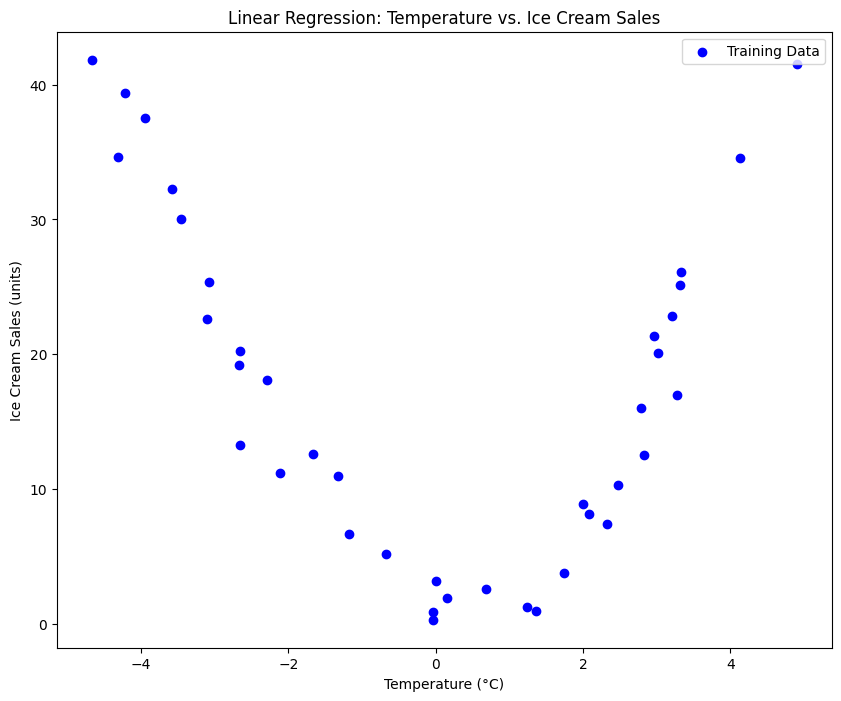

In [18]:
fig = plt.figure(figsize=(10, 8))

plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales (units)')
plt.title('Linear Regression: Temperature vs. Ice Cream Sales')
plt.legend()
plt.show()

## Model Training
We will train two models to compare their performance:
1. A standard **Simple Linear Regression** model.
2. A **Polynomial Regression** model (degree=19) to capture non-linear relationships.

In [19]:
lin = LinearRegression()
lin.fit(X, y)

poly = PolynomialFeatures(degree=19)
X_poly = poly.fit_transform(X)

poly.fit(X_poly, y)
lin2 = LinearRegression()
lin2.fit(X_poly, y)

LinearRegression()

## Linear Regression Plot
Visualizing how well the simple linear regression model fits the dataset.

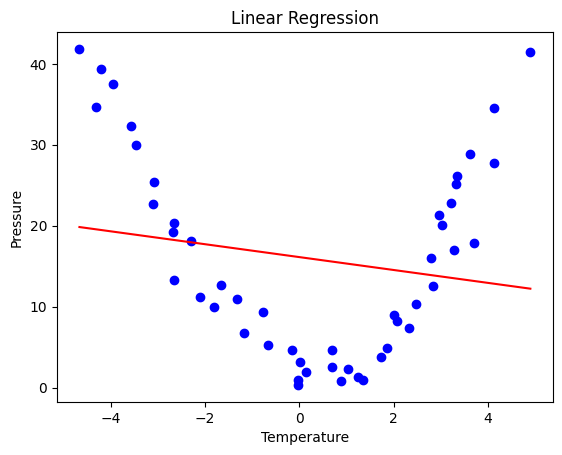

In [20]:
plt.scatter(X, y, color='blue')

plt.plot(X, lin.predict(X), color='red')
plt.title('Linear Regression')
plt.xlabel('Temperature')
plt.ylabel('Pressure')

plt.show()

## Linear Regression Evaluation
We evaluate the linear regression model on the test data using Mean Absolute Error (MAE) and R² Score.

In [21]:
y_pred = lin.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")
print(f"R² Score: {r2}")

Mean Absolute Error: 11.00376848456206
R² Score: -0.4048048415856942


## Polynomial Regression Plot
Now, let's visualize the curve plotted by the Polynomial Regression model.

Text(0, 0.5, 'Pressure')

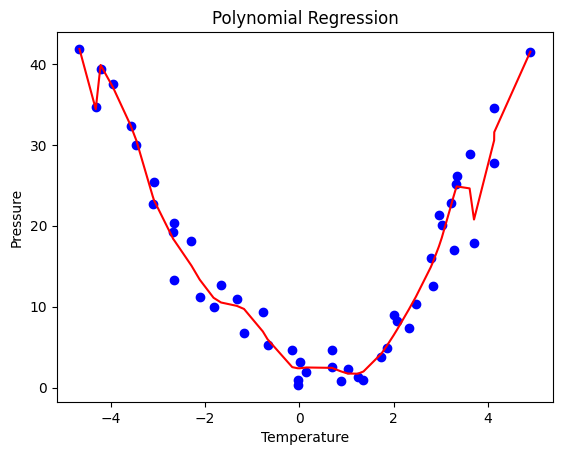

In [22]:
plt.scatter(X, y, color='blue')

plt.plot(X, lin2.predict(poly.fit_transform(X)),color='red')
plt.title('Polynomial Regression')
plt.xlabel('Temperature')
plt.ylabel('Pressure')

## Polynomial Regression Evaluation
Finally, we evaluate the polynomial regression model to see if it significantly outperformed the simple linear regression.

In [23]:
y_pred = lin2.predict(poly.transform(X_test))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")
print(f"R² Score: {r2}")

Mean Absolute Error: 2.104058462401574
R² Score: 0.9361440994792156
